# Imports

In [1]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path
from importlib import reload
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
import logging
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec, cm, set_loglevel
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase
from scipy.interpolate import interp1d

from astropy import stats
from astropy.io import fits
import astropy.units as u
import astropy.constants as const

In [2]:
# STARSHIPS
import starships.planet_obs as pl_obs
from starships.planet_obs import Observations, Planet

import starships.correlation_class as cc
from starships.correlation_class import Correlations
import starships.correlation as corr

import starships.homemade as hm
import starships.plotting_fcts as pf
import starships.spectrum as spectrum
from starships.mask_tools import interp1d_masked

interp1d_masked.iprint=False

import pipeline.reduction as red

# Injection

## Injection-recovery functions

In [3]:
def plot_scaled_model(wave_mod, mod_spec, mod_spec_scaled, path_fig=None):
    
    fig, axs = plt.subplots(2, 1, figsize=(9, 5), dpi=200, sharex=True)
    
    # Top panel: original model
    axs[0].plot(wave_mod, mod_spec * 1e6, label='Original model', linewidth=0.5, color="dodgerblue")
    axs[0].set_ylabel('Transit depth [ppm]', fontsize=12)
    axs[0].legend()

    # Bottom panel: scaled model
    axs[1].plot(wave_mod, 1 - mod_spec_scaled, label='Scaled model', linewidth=0.5, color="dodgerblue")
    axs[1].set_xlabel('Wavelength [μm]', fontsize=12)
    axs[1].legend()

    plt.tight_layout()
    
    if path_fig is not None:
        fig.savefig(str(path_fig) + '/scaled_model.pdf', bbox_inches='tight')
    
    plt.show()

In [4]:
def inj_rec(config_dict, p, obs, visit_name, wave_mod, mod_spec, plot_model=False, save_dir=None, path_fig=None, debug=False):

    ''' Takes as input a model and a raw data file to inject the model into at a given RV.
    Assumed a list of t.fits files for the night have already been made (so, that split nights has been run)
    
    wave_mod and mod_spec: outputs of petitradtrans model -- mod_spec should be in units of transit depth (R_pl/R_star)**2
    '''
    
    # Where to save the injected data files
    if save_dir == None:
        save_dir = Path(os.environ["SCRATCH"])
        save_dir /= Path(f'HRS_reductions/{config_dict["instrument"]}/{"".join(p.name.split())}/injected_data/{visit_name}/{config_dict["reduction"]}')
        save_dir.mkdir(parents=True, exist_ok=True)
    
    if path_fig == None:
        path_fig = save_dir / Path('Figures/')
        path_fig.mkdir(parents=True, exist_ok=True)

    # Check if this injection has already been done (if so, skip the injection)
    if (save_dir / "list_tcorr.txt").is_file():
        print(f"Injected data already exists: {visit_name}/{config_dict['reduction']}")
        return
    
    # Getting the exposures in and out of transit
    obs.calc_sequence(plot=False)
    in_transit = obs.iIn
    out_transit = obs.iOut

    # Getting the lightcurve
    exp_times = obs.t
    lightcurve = obs.alpha

    # Create the window function to scale the model 
    Wc = lightcurve / np.max(lightcurve)

    # Getting velocities for correction after
    obs.norv_sequence(RV=obs.planet.RV_sys.value[0])  # offset the RVs so that they are 0 at mid-transit
    
    vshift = -obs.berv0 + obs.RV_sys + obs.vrp + obs.mid_vrp + config_dict['RV_inj']

    # Scale the inputted model
    mod_spec_scaled = (mod_spec - (p.R_pl / p.R_star)**2) * config_dict['scaling_factor']

    if plot_model:
        # Save a plot of the scaled model
        plot_scaled_model(wave_mod, mod_spec, mod_spec_scaled, path_fig)

    # Get list of all exposures
    with open(str(config_dict['obs_dir']) + '/' + 'list_tcorr.txt') as f:
        exp_list = f.readlines()

    # Initialize lists to store data
    wavelengths = []
    counts = []

    for i, exp in enumerate(exp_list):

        # Shift the model wavelength into the observer rest frame for this exposure
        wave_mod_shifted = wave_mod * (1 + vshift[i] / 299792.458)

        # Setup a function to interpolate over the model
        interp_wavelength = interp1d(wave_mod_shifted, mod_spec_scaled, kind='cubic', bounds_error=False, fill_value=0.)
        
        if debug:
            # Plot each exposure
            plt.figure(figsize=(8,3), dpi=200)
        
        # load the exposure
        with fits.open(str(config_dict['obs_dir']) + '/' + exp.strip(), memmap=False) as hdul:

            count = hdul[1].data  # copy of the flux data
            wv = hdul[2].data / 1000
            
            new_count = count.copy()  # create a copy to modify

            # Iterate over the orders
            for w in range(len(wv)):

                if debug:
                    # Plot original 
                    if w == 0: plt.plot(wv[w], count[w], label='Original', zorder=1)
                    else: plt.plot(wv[w], count[w], zorder=1)

                # Interpolate the model to the wavelength, and scale by the lightcurve
                mod_interp = 1 - interp_wavelength(wv[w]) * Wc[i]

                # Multiply the count by the model in that range
                new_count[w] = count[w] * mod_interp

                if debug:
                    # Plot new
                    if w == 0: plt.plot(wv[w], new_count[w], label='Injected', color = 'blue', zorder=0)
                    else: plt.plot(wv[w], new_count[w], color = 'blue', zorder=0)
            
            # Assign the modified data back to the HDU
            hdul[1].data = new_count

            # Save to new fits file with same name, in new folder
            hdul.writeto(str(save_dir / exp.strip()), overwrite=True)

            # Append wavelengths and counts for this exposure to the lists
            wavelengths.append(wv)
            counts.append(hdul[1].data)

            if debug:
                plt.title(f'Exposure {i + 1}')
                plt.legend()
                # plt.show()

    # Copy e2ds files into scratch so we can use it as a new obs_dir
    # Get list of all exposures
    with open(str(config_dict['obs_dir']) + '/' + f'list_e2ds.txt') as f:
        e2ds_list = f.readlines()

    for i, e2ds in enumerate(e2ds_list):
        os.system(f'cp {config_dict["obs_dir"]}/{e2ds.strip()} {save_dir}')

    # Copy the e2ds and tcorr lists into the scratch
    os.system(f'cp {config_dict["obs_dir"]}/list_tcorr.txt {save_dir}')
    os.system(f'cp {config_dict["obs_dir"]}/list_e2ds.txt {save_dir}')


## Injection setup

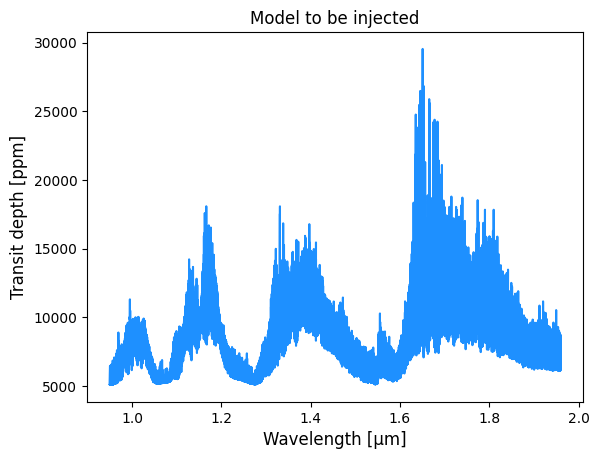

In [5]:
# INFORMATION
pl_name = "TRAPPIST-1 d"
instrument = "NIRPS_Apr2026"  # SPIRou_with_persi, NIRPS

# PARAMETERS OF THE PLANET
RVsys  = -52.003101*u.km/u.s  # RV of star system, source: Simbad

# MODEL DETAILS
molecule = 'CH4'
scenario = 'H2rich'
ab = 0.01
cloud = 100

# model_directory = "/home/mathisb/Github/HRS_models/"  # where to find the models
# model_filename_1 = "prt_model_TRAPPIST-1f"
# model_filename_2 = "CH4_NIRPS_H2rich.npz"  # CO2, CH4, H2O

# ########################### TEMP
model_directory = f"/home/mathisb/scratch/HRS_models/{pl_name[-1]}_{scenario}_{molecule}/"
model_filename_1 = f"prt_model_TRAPPIST-1{pl_name[-1]}"
model_filename_2 = f"{scenario}_{molecule}_{str(ab)}_pcloud_{str(cloud)}.npz"
# ##########################

scaling = 1  # scaling factor to multiply the model (transit depth) with
RV_inj = -50  # RV where to inject the signal

#----------------------------------------------------------------#

model_filename = model_filename_1 + '_' + model_filename_2
model_name = model_filename_2[:-4]
model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

if 'NIRPS' in instrument:
    # cut off the model at the NIRPS wavelengths
    model_spec = model_spec[wave_mod <= 1.96]
    wave_mod = wave_mod[wave_mod <= 1.96]

# Reduction version
reduction = f"injected_{model_name}_at{RV_inj}_scaling{scaling}"

# Plot it
plt.plot(wave_mod, model_spec * 1e6, color="dodgerblue")

plt.xlabel('Wavelength [μm]', fontsize=12)
plt.ylabel('Transit depth [ppm]', fontsize=12)  # transit depth: $(\frac{R_{\rm p}}{R_{\rm \star}})^2$
plt.title('Model to be injected')
plt.show()

In [6]:
# SOME IMPORTANT DICTIONARIES

# Lists of data files
list_filenames = {'list_e2ds': 'list_e2ds.txt',
                  'list_tcorr': 'list_tcorr.txt'}


if pl_name == 'TRAPPIST-1 b':
    ap     = 0.01154*u.au        # semi-major axis of planet
    R_pl   = 1.116*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 d':
    ap     = 0.02227*u.au        # semi-major axis of planet
    R_pl   = 0.788*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 e':
    ap     = 0.02925*u.au        # semi-major axis of planet
    R_pl   = 0.920*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 f':
    ap     = 0.03849*u.au        # semi-major axis of planet
    R_pl   = 1.045*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

elif pl_name == 'TRAPPIST-1 g':
    ap     = 0.04683*u.au        # semi-major axis of planet
    R_pl   = 1.129*u.R_earth     # radius of planet
    R_star = 0.1192*u.R_sun      # radius of star
    M_star = 0.0898*const.M_sun  # mass of star
    e      = 0                   # eccentricity
    w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

else:
    raise ValueError(f"Please add the params for planet {pl_name}.")


# Mid-transit time (BJD) of each TRAPPIST-1 visit (calculated from Agol et al. 2024)
mid_tr_dict = {
        # SPIRou b
               "2019-06-14": 2458649.07123371738 * u.d,
               "2019-09-25": 2458751.8112203472  * u.d,
               "2020-05-31": 2459001.10676193183 * u.d,
               "2020-08-04": 2459066.07481311538 * u.d,
               "2020-09-08": 2459100.82490738839 * u.d,
               "2020-09-20": 2459112.91190875796 * u.d,
               "2020-09-26": 2459118.95517847751 * u.d,
               "2020-09-29": 2459121.9775049779  * u.d,
               "2021-10-21": 2459508.76251261068 * u.d,
               "2021-10-24": 2459511.78471495466 * u.d,
               "2021-10-27": 2459514.8059938763  * u.d,
        # NIRPS b
               "2023-09-07": 2460194.7007329288  * u.d,
               "2024-07-05": 2460496.8725766301  * u.d,
               "2024-07-11b": 2460502.9159761349 * u.d,
        # NIRPS d
               "2023-06-08": 2460103.8951073092 * u.d,
               "2023-08-12": 2460168.6902942523 * u.d,
               "2023-08-24": 2460180.8397053848 * u.d,
               "2023-10-20": 2460237.5365671548 * u.d,
        # NIRPS e
               "2023-07-17": 2460142.858565431  * u.d,
               "2023-11-04": 2460252.6376593957 * u.d,
               "2024-07-11e": 2460502.7365562134 * u.d,
        # NIRPS f
               "2023-08-28": 2460184.827486578  * u.d,
               "2024-11-02": 2460617.5481359637 * u.d,
               "2025-08-06": 2460893.795434583  * u.d,
        # NIRPS g
               "2023-10-05": 2460222.5638302773 * u.d,
               "2023-11-11": 2460259.6204310769 * u.d,
               "2025-07-08": 2460864.8974261757 * u.d,
                }


# Planet parameters dict
pl_kwargs = {'M_star': M_star, 
             'R_star': R_star,
             'ap': ap,
             'R_pl': R_pl,
             'excent': e,
             'w': w}


# Data required for the injection
config_dict = {
                "instrument" : instrument,
                "reduction" : reduction,
                'scaling_factor' : scaling,
                'RV_inj' : RV_inj,
              }

### Finding out the max scaling I can use with a model

In [11]:
find_max_scale = False
scaling_test = 1000

if find_max_scale:
    # Model tr depth - tr depth of bare rock
    mod_spec_above0 = model_spec - (R_pl / R_star)**2
    plt.plot(wave_mod, mod_spec_above0 * 1e6, color="darkblue")
    plt.title("Original model minus transit depth of bare rock")
    plt.ylabel("ppm")
    plt.show()

    # The above but with scaling
    mod_spec_above0_scaled = mod_spec_above0 * scaling_test
    plt.plot(wave_mod, mod_spec_above0_scaled * 1e6, color="g")
    plt.hlines(1e6, wave_mod.min(), wave_mod.max(), ls="--", color="r", label="Do not go over this")
    plt.title("Scaled model")
    plt.ylabel("ppm")
    plt.show()

## Run the injection

In [7]:
# Where to inject a signal
nightlist = [
    # SPIRou b
            # "2019-06-14",
            # "2019-09-25",
            # "2020-05-31",
            # "2020-08-04",
            # "2020-09-08",
            # "2020-09-20",
            # "2020-09-26",
            # "2020-09-29",
            # "2021-10-21",
            # "2021-10-24",
            # "2021-10-27"
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            # '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            # '2023-11-11',
            # '2025-07-08',
               ]

# Where to save the injected data files
save_dir = None  # if None, saved in scratch/HRS_reductions/{instrument}/{planet}/injected_data/{visit_name}/{reduction}

#---------------------------------------------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print all the log information

for visit_name in nightlist:
    # Directory where the data is
    obs_dir = f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{visit_name}/"
    config_dict['obs_dir'] = obs_dir
    
    mid_tr = mid_tr_dict[visit_name]

    if 'SPIRou' in instrument: instr_name = 'SPIRou-APERO'
    elif 'NIRPS' in instrument: instr_name = 'NIRPS-APERO'
    
    # Create obs and planet objects
    obs_inj = Observations(name=pl_name, instrument=instr_name,
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'mid_tr': mid_tr,
                                't_peri': mid_tr,
                                'excent': e,
                                'w': w,
                                'RV_sys': RVsys})

    obs_inj.fetch_data(obs_dir, **list_filenames, CADC=True)
    p = obs_inj.planet
    
    # Inject
    inj_rec(config_dict, p, obs_inj, visit_name, wave_mod, model_spec, plot_model=True, save_dir=save_dir, debug=False)


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Injected data already exists: 2023-06-08/injected_H2rich_CH4_0.01_pcloud_100_at-50_scaling1


# Reduction

## Run the reduction

In [13]:
# PARAMETERS TO CHANGE

kind_trans = 'transmission'  # emission or transmission
coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'

nPC = [1]  # number of principal components to remove
tellu_frac = 0.40  # telluric fraction to mask (usually varied between 0.2 and 0.5)
mask_wings = 0.97  # fraction of wings of deep tellurics to mask

#---------------------------------------------------------------------------------#

# Fixed parameters
cbp = True  # correct bad pixels
iout_all = ['all']
polynome = [False] 
do_tr = [1]
transit_tags = [None]  # use if want to remove spectra

kwargs_gen_tr = {
    'coeffs' : coeffs,
    'ld_model' : ld_model,
    'do_tr' : do_tr,
    'kind_trans' : kind_trans,
    'polynome' : polynome,
    'cbp': cbp }

kwargs_build_ts = {
    'clip_ratio' : 6,
    'clip_ts' : 6,
    'unberv_it' : True }

obs_dict = {}

pl_obs.log.setLevel("WARNING")  # do not print all the log information


for visit_name in nightlist:
    
    # Where to output the reductions
    pl_name_fname = ''.join(pl_name.split())
    out_dir = Path(os.environ['SCRATCH']) / f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}'
    out_dir.mkdir(parents=True, exist_ok=True)  # make sure the directory exist

    # Directory with the injected data files
    inj_dir = f"/home/mathisb/scratch/HRS_reductions/{instrument}/{pl_name_fname}/injected_data/{visit_name}/{reduction}"
    
    # Where to save figures
    path_fig = out_dir / Path('Figures/')
    path_fig.mkdir(parents=True, exist_ok=True)  # make sure the  directory exists
    
    mid_tr = mid_tr_dict[visit_name]

    if 'SPIRou' in instrument: instr_name = 'SPIRou-APERO'
    elif 'NIRPS' in instrument: instr_name = 'NIRPS-APERO'
    
    # Create obs object
    obs = Observations(name=pl_name, instrument=instr_name,
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'mid_tr': mid_tr,
                                't_peri': mid_tr,
                                'excent': e,
                                'w': w,
                                'RV_sys': RVsys})

    obs.fetch_data(inj_dir, **list_filenames, CADC=True)
    obs_dict[visit_name] = obs
    
    # Do the reduction
    for n_pc in nPC:

        # Check if this reduction has already been done (if so, skip it)
        out_filename1 = f'sequence_{n_pc}-pc_mask_wings{mask_wings*100:n}'
        out_filename2 = f'retrieval_input_{n_pc}-pc_mask_wings{mask_wings*100:n}'

        out_filename1_full = out_dir / (out_filename1 + f'_data_trs_{visit_name}.npz')

        if out_filename1_full.is_file():
            print(f"Reduction already exists: {visit_name}/{reduction}/{out_filename1}")
            continue

        params_all=[[tellu_frac, mask_wings, 51, 41, 5, n_pc, 5.0, 5.0, 5.0, 5.0]]
        list_tr = pl_obs.generate_all_transits(obs_dict[visit_name], transit_tags, [RVsys.value], params_all, iout_all, **kwargs_gen_tr, **kwargs_build_ts)
        
        # Save sequence with all reduction steps
        pl_obs.save_single_sequences(out_filename1, list_tr['1'], path=out_dir, filename_end=visit_name, save_all=True)

        # Save sequence with only the info needed for a retrieval (to compute log likelihood)
        pl_obs.save_sequences(out_filename2, list_tr, do_tr, path=out_dir)
    

pl_obs.log.setLevel("INFO")  # go back to normal log printing


Reduction already exists: 2023-06-08/injected_H2rich_CH4_0.01_pcloud_100_at-50_scaling1/sequence_1-pc_mask_wings97


## Plot the reduction

In [14]:
# LOAD ALL THE REDUCTIONS

# If needed, specify the nights, nPC and mask_wings to plot (otherwise None)
night_plot = None
nPC_plot = [1]  # also the nPC used for the correlation
mask_wings_plot = [97]

#----------------------------------#

night_plot = night_plot or nightlist
nPC_plot = nPC_plot or nPC
mask_wings_plot = mask_wings_plot or [int(mask_wings * 100)]

seq_files = [
    f"sequence_{n}-pc_mask_wings{m}_data_trs_{visit}.npz"
    for visit in night_plot
    for n in nPC_plot
    for m in mask_wings_plot
]

# Load all sequence objects and put them in a list
seq_obj_list = []

for seq in seq_files:
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    print(f"Loading {seq_visit} |", f"{seq[:-4].split('_')[1]}, {seq[:-4].split('_')[2]}" + f"_{seq[:-4].split('_')[3]}")

    # Create the planet object
    mid_tr = mid_tr_dict[seq_visit]
    pl_kwargs['mid_tr'] = mid_tr
    pl_kwargs['t_peri'] = mid_tr

    planet_obj = Planet(pl_name, **pl_kwargs)
    
    path_reduc = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{seq_visit}/{reduction}')
    seq_obj = pl_obs.load_single_sequences(seq, name=pl_name, planet=planet_obj, path=path_reduc, load_all=True, plot=False)
    seq_obj_list.append(seq_obj)

print("Done")

INFO:starships.planet_obs:Getting TRAPPIST-1 d from ExoFile


Loading 2023-06-08 | 1-pc, mask_wings97


INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.78559206388685e+29 kg
INFO:starships.planet_obs:It became [1.78559206e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.1192 solRad
INFO:starships.planet_obs:It became [82927440.] m
INFO:starships.planet_obs:Changing ap from [3.3300486e+09] m to 0.02227 AU
INFO:starships.planet_obs:It became [3.33154458e+09] m
INFO:starships.planet_obs:Changing R_pl from [4932948.] m to 0.788 earthRad
INFO:starships.planet_obs:It became [5025942.8] m
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00837 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [4.56002174] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.planet_obs:Changing mid_tr from [2457670.146301] d to 2460103.8951073093 d
INFO:starships.planet_obs:It became [2460103.89510731] d
INFO:starships.planet_obs:Changing t_peri from [2457670.146301] d to 246010

Done


### Some more optional plots

In [ ]:
for seq_obj in seq_obj_list:
    pf.plot_airmass([seq_obj])

Reduction steps: 2024-07-11b


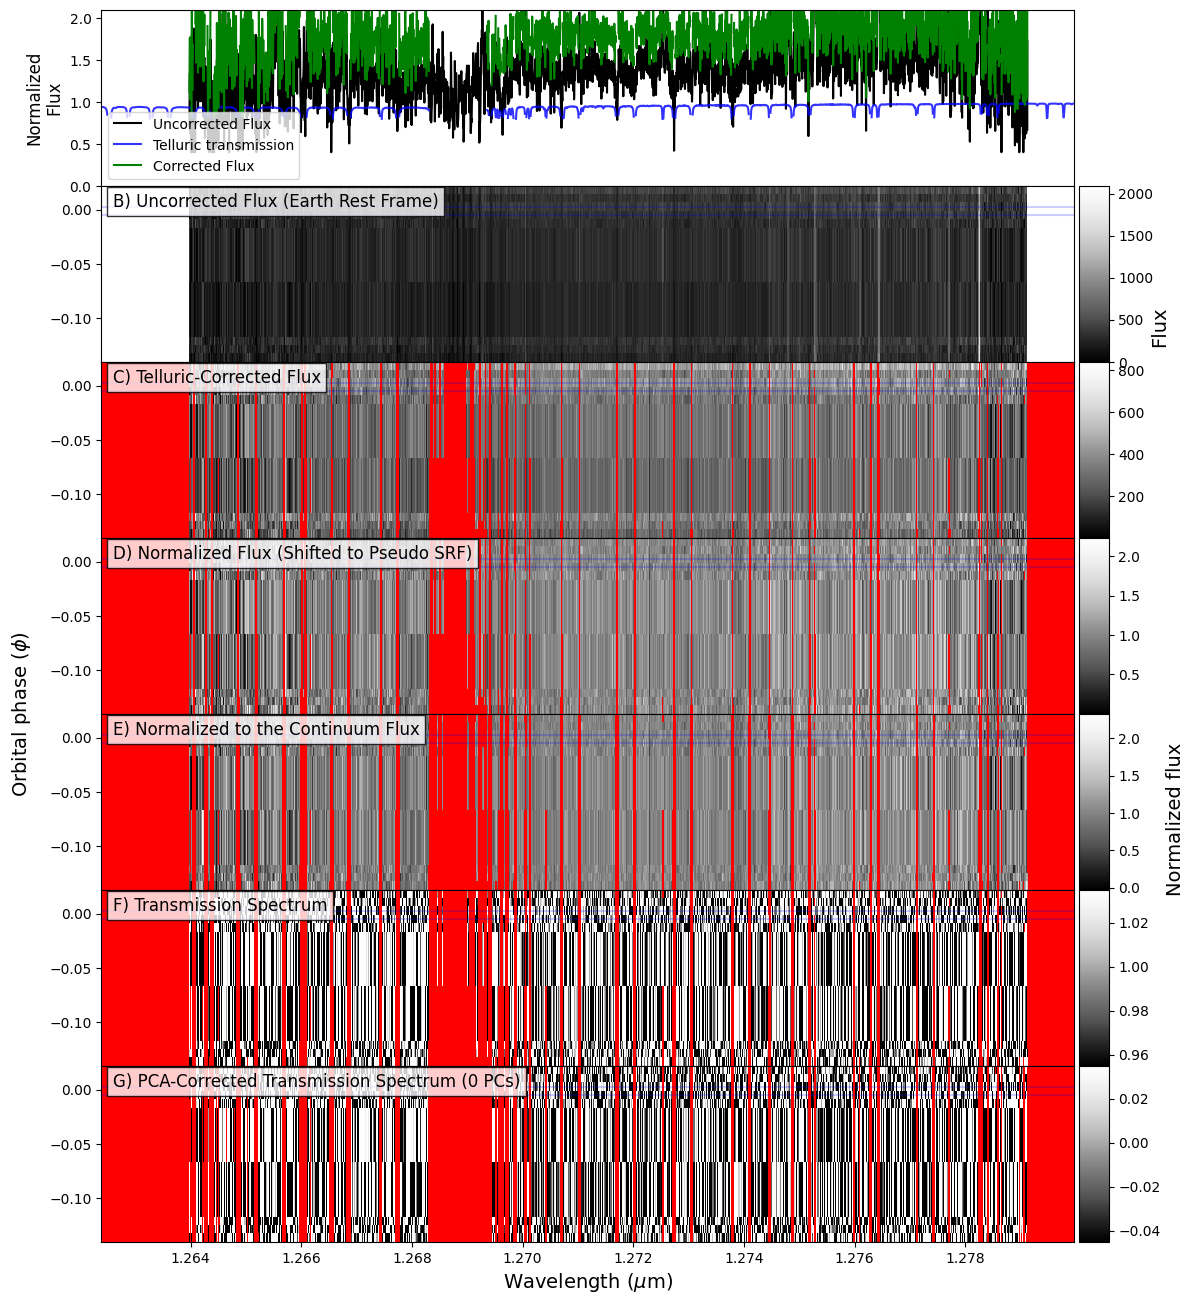

In [37]:
# PLOT THE REDUCTION STEPS

# Order to plot
order_plot = 36

#--------------#

for i, seq in enumerate(seq_files):
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    print(f'\033[1mReduction steps: {seq_visit}\033[0m')
    plot_steps = pf.plot_steps(seq_obj_list[i], order_plot - 1)


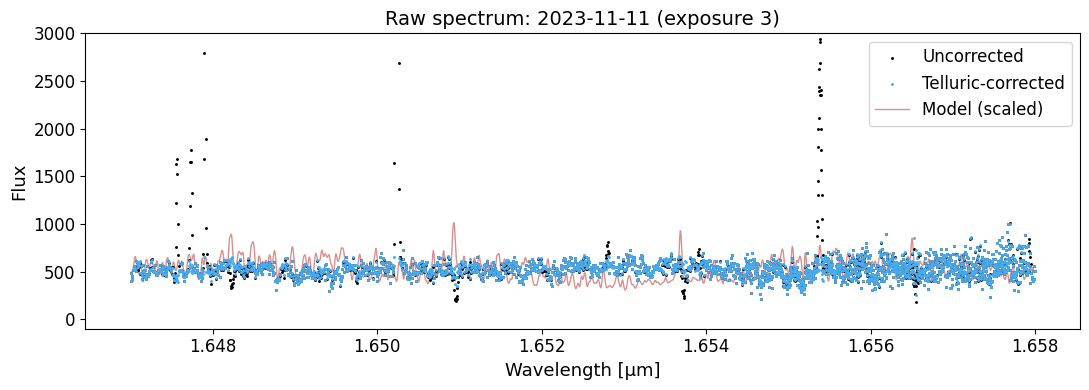

In [109]:
# PLOT RAW AND TELLURIC-CORRECTED SPECTRUM WITH OVERLAPPING ORDERS

wv_range = [1.647, 1.658]  # wavelength range to plot, in microns

use_median = False  # plot the median flux of all exposures
exp_plot = 3  # exposure to plot (ignored if use_median = True)

ylims = [-100, 3000]  # specify y axis limits

#--------------------------------------------#

plotted_visits = []  # keep track of visits already plotted

for i, seq in enumerate(seq_files):
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    
    if seq_visit in plotted_visits:
        continue
    
    pf.plot_raw_spectrum(seq_obj_list[i], wv_range, seq_visit, use_median=use_median, exp_plot=exp_plot, ylims=ylims)
    plotted_visits.append(seq_visit)


In [16]:
def plot_for_Nic(observation, wv_range, visit_name, use_median=True, exp_plot=10, compare_model=False, model_wav=None, model_spec=None, ylims=None):
    # ----------------------- sanity checks ----------------------------- #
    if wv_range[0] >= wv_range[1]:
        raise ValueError("wavelength_range must be (min, max) with min < max.")

    if not use_median and not (1 <= exp_plot < observation.uncorr.shape[0]):
        raise IndexError("exp_plot is out of bounds for the number of exposures.")
        
    if compare_model and (model_wav is None or model_spec is None):
        raise ValueError("model_wav and model_spec must be given when compare_model=True.")

    # -------------------- blaze‑function correction -------------------- #
    # Divide by the blaze to get a spectrum normalized at 1
    blaze_norm = observation.blaze / np.nanmax(observation.blaze, axis=-1, keepdims=True)
    uncorrected_flux = observation.uncorr / blaze_norm

    # ------------------ build 1‑D concatenated spectra ----------------- #
    order_indices = np.arange(observation.nord)  # array with all the orders

    # Concatenate wavelength values across orders
    wavelength = np.concatenate([observation.wv[i] for i in order_indices])

    if use_median:
        # Median across exposures, order by order
        flux_uncorrected = np.concatenate([np.nanmedian(uncorrected_flux, axis=0)[i] for i in order_indices])
        flux_corrected = np.concatenate([np.nanmedian(observation.flux, axis=0)[i] for i in order_indices])
    else:
        flux_uncorrected = np.concatenate([uncorrected_flux[exp_plot - 1, i] for i in order_indices])
        flux_corrected = np.concatenate([observation.flux[exp_plot - 1, i] for i in order_indices])

    # ----------------------- wavelength mask --------------------------- #
    mask = (wv_range[0] < wavelength) & (wavelength < wv_range[1])
    
    # ---------------------------- plot --------------------------------- #
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.scatter(wavelength[mask], flux_corrected[mask], s=1.2, c="#48ACF0", label="Telluric‑corrected",zorder=4)
    
    # --------------- optional model backdrop --------------------------- #
    if compare_model:
        # Mask model to requested wavelength range
        model_mask = (wv_range[0] < model_wav) & (model_wav < wv_range[1])
        model_wav_in = model_wav[model_mask]
        model_spec_in = model_spec[model_mask]
        
        # Interpolate model to data wavelength grid
        interp_func = sp.interpolate.interp1d(model_wav_in, model_spec_in, kind='cubic', bounds_error=False, fill_value="extrapolate")
        interp_model_spec = interp_func(wavelength[mask])
        
        flux_outoftr = np.concatenate([observation.flux[1, i] for i in order_indices])
        
        model_times_Fout = interp_model_spec * flux_outoftr[mask]
        
        ax.plot(wavelength[mask], model_times_Fout, color="firebrick", linewidth=1, alpha=0.5,
                label="Model (scaled) * F_out", zorder=0)

    # --------------- labels, limits, legend ---------------------------- #
    ax.set_xlabel("Wavelength [μm]", fontsize=13)
    ax.set_ylabel("Flux", fontsize=13)

    # Plot title
    if use_median:
        title = f"Raw spectrum: {visit_name} (median of exposures)"
    else:
        title = f"Raw spectrum: {visit_name} (exposure {exp_plot})"
    
    # Set limits for the y axis
    if ylims is not None:
        ax.set_ylim(ylims)
    
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.show()
    


def plot_inj_data(observation, noninj_data, wv_range, visit_name, use_median=True, exp_plot=10, ylims=None):
    # ----------------------- sanity checks ----------------------------- #
    if wv_range[0] >= wv_range[1]:
        raise ValueError("wavelength_range must be (min, max) with min < max.")

    if not use_median and not (1 <= exp_plot < observation.uncorr.shape[0]):
        raise IndexError("exp_plot is out of bounds for the number of exposures.")

    # -------------------- blaze‑function correction -------------------- #
    # Divide by the blaze to get a spectrum normalized at 1
    blaze_norm = observation.blaze / np.nanmax(observation.blaze, axis=-1, keepdims=True)
    uncorrected_flux = observation.uncorr / blaze_norm
    
    # SAME BUT FOR NONINJ DATA
    blaze_norm_noninj = noninj_data.blaze / np.nanmax(noninj_data.blaze, axis=-1, keepdims=True)
    uncorrected_flux_noninj = noninj_data.uncorr / blaze_norm_noninj

    # ------------------ build 1‑D concatenated spectra ----------------- #
    order_indices = np.arange(observation.nord)  # array with all the orders

    # Concatenate wavelength values across orders
    wavelength = np.concatenate([observation.wv[i] for i in order_indices])

    if use_median:
        # Median across exposures, order by order
        flux_uncorrected = np.concatenate([np.nanmedian(uncorrected_flux, axis=0)[i] for i in order_indices])
        flux_corrected = np.concatenate([np.nanmedian(observation.flux, axis=0)[i] for i in order_indices])
        
        # SAME BUT FOR NONINJ DATA
        flux_uncorrected_noninj = np.concatenate([np.nanmedian(uncorrected_flux_noninj, axis=0)[i] for i in order_indices])
        flux_corrected_noninj = np.concatenate([np.nanmedian(noninj_data.flux, axis=0)[i] for i in order_indices])
        
    else:
        flux_uncorrected = np.concatenate([uncorrected_flux[exp_plot - 1, i] for i in order_indices])
        flux_corrected = np.concatenate([observation.flux[exp_plot - 1, i] for i in order_indices])
        
        # SAME BUT FOR NONINJ DATA
        flux_uncorrected_noninj = np.concatenate([uncorrected_flux_noninj[exp_plot - 1, i] for i in order_indices])
        flux_corrected_noninj = np.concatenate([noninj_data.flux[exp_plot - 1, i] for i in order_indices])

    # ----------------------- wavelength mask --------------------------- #
    mask = (wv_range[0] < wavelength) & (wavelength < wv_range[1])
    
    # ---------------------------- plot --------------------------------- #
    fig, ax = plt.subplots(figsize=(11, 4))
    # ax.scatter(wavelength[mask], flux_uncorrected[mask], s=1.2, c="#21eb8c", label="Injected data", zorder=3)
    # ax.scatter(wavelength[mask], flux_uncorrected_noninj[mask], s=1.2, c="k", label="Non-injected data", zorder=2)
    
    ax.scatter(wavelength[mask], flux_uncorrected[mask] - flux_uncorrected_noninj[mask], s=1.2, c="r", label="Injected data − non-injected data", zorder=2)

    # --------------- labels, limits, legend ---------------------------- #
    ax.set_xlabel("Wavelength [μm]", fontsize=13)
    ax.set_ylabel("Flux", fontsize=13)

    # Plot title
    if use_median:
        title = f"Injected vs raw spectrum: {visit_name} (median of exposures)"
    else:
        title = f"Injected vs raw spectrum: {visit_name} (exposure {exp_plot})"
    
    # Set limits for the y axis
    if ylims is not None:
        ax.set_ylim(ylims)
    
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

    plt.tight_layout()
    plt.show()


In [17]:

do_plot_for_Nic = False

wv_range = [1.5, 1.63]  # wavelength range to plot, in microns

use_median = False  # plot the median flux of all exposures
exp_plot = 9  # exposure to plot (ignored if use_median = True)

compare_model = True  # plot model as backdrop, to compare

ylims = [-100, 5000]  # specify y axis limits

#--------------------------------------------#

if do_plot_for_Nic:
    plotted_visits = []  # keep track of visits already plotted
    model_to_plot = 1 - ((model_spec - (p.R_pl / p.R_star) **2) * scaling_test + (p.R_pl / p.R_star) **2)

    for i, seq in enumerate(seq_files):
        seq_visit = seq[:-4].split('_')[-1]  # get the visit name

        if seq_visit in plotted_visits:
            continue

        plot_for_Nic(seq_obj_list[i], wv_range, seq_visit, use_median=use_median, exp_plot=exp_plot,
                             compare_model=compare_model, model_wav=wave_mod, model_spec=model_to_plot, ylims=ylims)
        plotted_visits.append(seq_visit)


In [ ]:

do_plot_inj_data = True

wv_range = [1.5, 1.63]  # wavelength range to plot, in microns

use_median = False  # plot the median flux of all exposures
exp_plot = 10  # exposure to plot (ignored if use_median = True)

ylims = [-2, 5]  # specify y axis limits

#--------------------------------------------#

if do_plot_inj_data:
        plotted_visits = []  # keep track of visits already plotted

        for seq in seq_files:
            seq_visit = seq[:-4].split('_')[-1]  # get the visit name

            if seq_visit in plotted_visits:
                continue
            
            # Fetch the non injected data
            data_reduc = "v006" if seq_visit == "2019-09-25" else "v001"
            path_reduc_noninj = Path(f'/home/mathisb/Github/HRS_reductions/{instrument}/{pl_name_fname}/{seq_visit}/{data_reduc}')
            noninj_data = pl_obs.load_single_sequences(seq, name=pl_name, planet=p, path=path_reduc_noninj, load_all=True, plot=False)
            
            seq_obj_list[i].fetch_data(f"/home/mathisb/scratch/HRS_reductions/{instrument}/{pl_name_fname}/injected_data/{seq_visit}/{reduction}", **list_filenames, CADC=True)
            noninj_data.fetch_data(f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{seq_visit}/", **list_filenames, CADC=True)
            
            plot_inj_data(seq_obj_list[i], noninj_data, wv_range, seq_visit, use_median=use_median, exp_plot=exp_plot, ylims=ylims)
            plotted_visits.append(seq_visit)

# Correlations

## Run the correlations

In [18]:

# Define cross-correlation axes
step_RV_inj = 1.0  # SPIROU: 2.14 (twice the resolution of SPIRou in km/s); NIRPS: 1.0
corr_xlim = 100  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

#-------------------------------------------------------------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print all the log information

# Correlation setup
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)

n_pc_list = []
mask_wings_list = []
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()


# Run the correlation
for seq in seq_files:
    
    # Filenames and paths
    seq_visit = seq[:-4].split('_')[-1]  # get the visit name
    path_reduc = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{seq_visit}/{reduction}')  # where to find the reductions
    path_corr = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{seq_visit}/{reduction}')  # where to output the correlations
    path_corr.mkdir(parents=True, exist_ok=True)  # create output directory if it does not exist

    # Create the planet object
    mid_tr = mid_tr_dict[seq_visit]
    pl_kwargs['mid_tr'] = mid_tr
    pl_kwargs['t_peri'] = mid_tr

    planet_obj = Planet(pl_name, **pl_kwargs)
    
    # Load the observation
    obs = pl_obs.load_single_sequences(seq, pl_name, planet=planet_obj, path=path_reduc, load_all=False, filename_end='', plot=False)

    # Generate Kp 
    Kp_array = np.array([obs.Kp.value]) 

    n_pc = int(obs.params[5])
    n_pc_list.append(n_pc)

    mask_wings = int(obs.params[1] * 100)
    mask_wings_list.append(mask_wings)

    out_filename = f'{Path(seq).stem}_ccf_logl_seq_{model_name}'

    try:
        # Check if already generated
        saved_values = np.load(path_corr / Path(out_filename + '.npz'))
        print("Loading", seq_visit, "correlation...")
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']

    except FileNotFoundError:
        # Generate 1d correlations
        # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs, 'seq', p, Kp_array, corrRV0,
                                                  [n_pc], wave_mod, model_spec, kind_trans)

        # Save the correlation in a file
        corr.save_logl_seq(path_corr / Path(out_filename), ccf_map, logl_map,
                           wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)

    all_obs[(seq_visit, n_pc, mask_wings)] = obs
    all_ccf_map[(seq_visit, n_pc, mask_wings)] = ccf_map
    all_logl_map[(seq_visit, n_pc, mask_wings)] = logl_map

pl_obs.log.setLevel("INFO")  # go back to normal log printing

Loading 2023-06-08 correlation...


## Plot the correlations

**Cross-correlation time series in planet rest frame**

2023-06-08
Orders used in the analysis: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]
Max value at 1 nPC = 0.6092500948798486 at 4.258048404591158 km/s
Max value at 1 nPC = 0.5566583111236579 at 4.265923240403398 km/s
Max value at 1 nPC = 0.5566583111236579 at 4.265923240403398 km/s


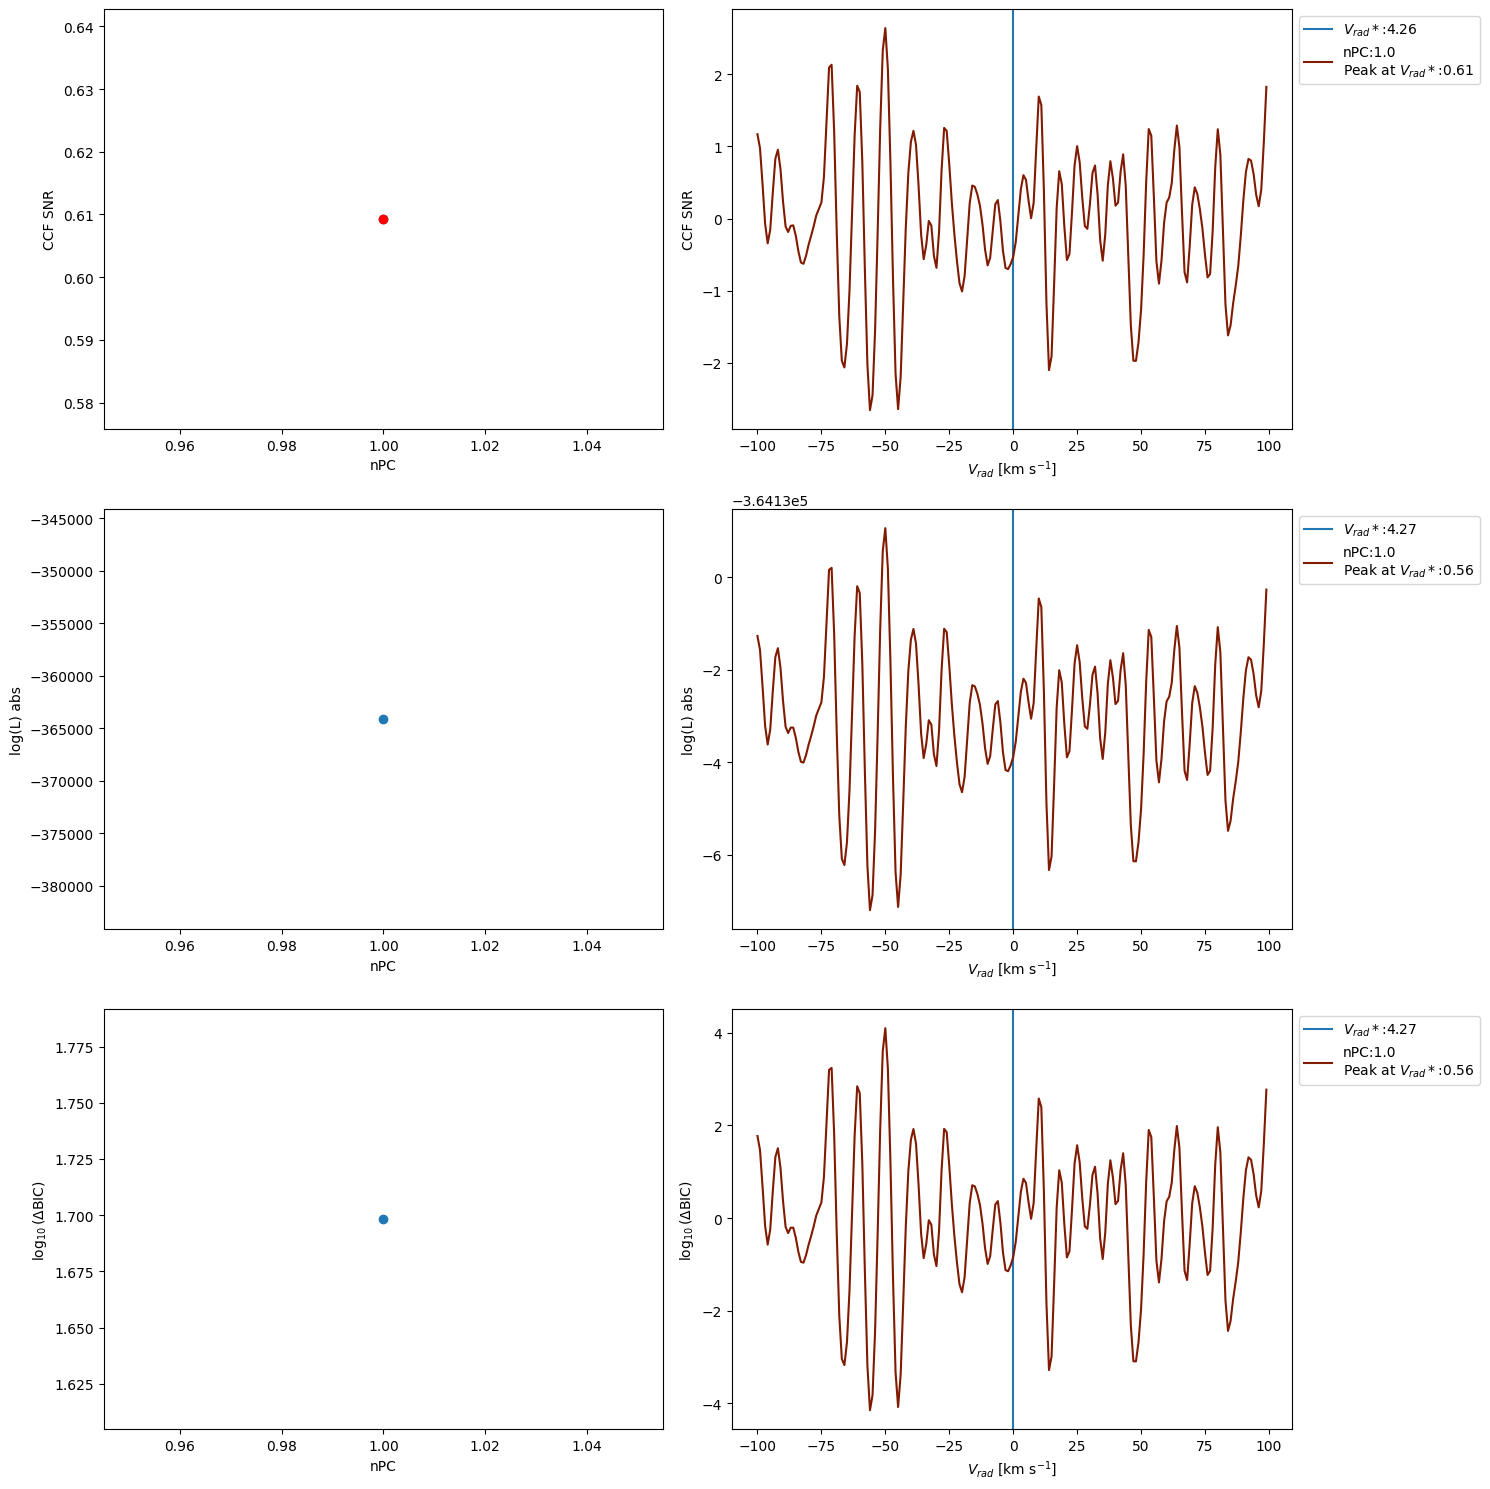

CCF SNR peak at Vrad*: [0.60925009]
log(L) abs peak at Vrad*: [-364132.19105814]
log_10(ΔBIC) peak at Vrad*: [1.69822642]
Saved file to :  /scratch/mathisb/HRS_correlations/NIRPS_Apr2026/TRAPPIST-1d/2023-06-08/injected_H2rich_CH4_0.01_pcloud_100_at-50_scaling1/Figures/fig_CCF_2Dsequence_1-pc_mask_wings97_data_trs_2023-06-08_ccf_logl_seq_H2rich_CH4_0.01_pcloud_100_pc1.pdf
In-transit t-val = 0.40 / p-val 6.97e-01 / sig = -0.52
Out-of-transit t-val = -0.54 / p-val 5.97e-01 / sig = -0.25


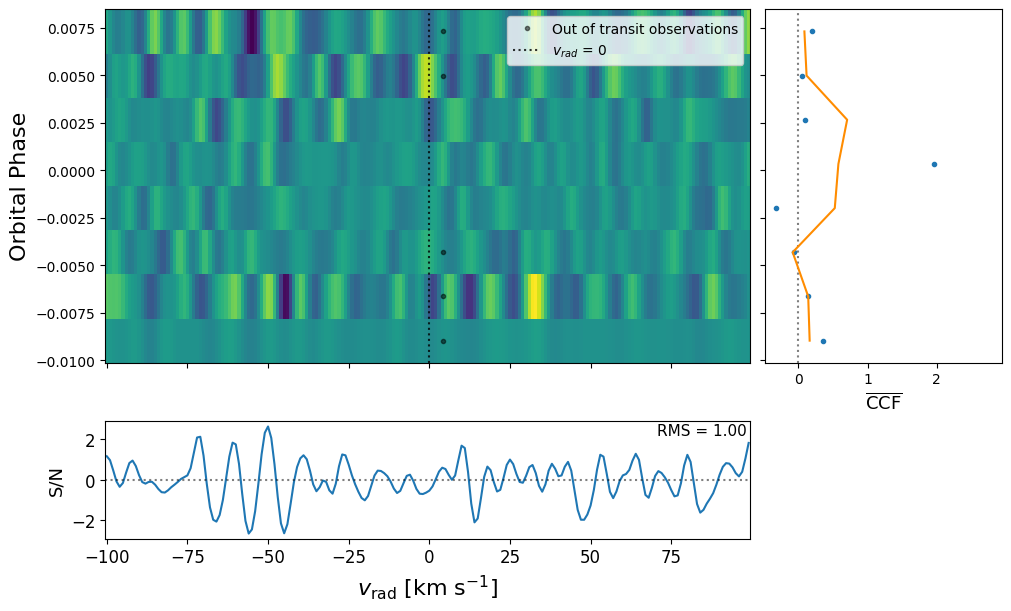

In [19]:
# List of nights to plot
nights_plot = [
    # SPIRou b
            # "2019-06-14",
            # "2019-09-25",
            # "2020-05-31",
            # "2020-08-04",
            # "2020-09-08",
            # "2020-09-20",
            # "2020-09-26",
            # "2020-09-29",
            # "2021-10-21",
            # "2021-10-24",
            # "2021-10-27"
    # NIRPS b
            # '2023-09-07',
            # '2024-07-05',
            # '2024-07-11b',
    # NIRPS d
            '2023-06-08',
            # '2023-08-12',
            # '2023-08-24',
            # '2023-10-20',
    # NIRPS e
            # '2023-07-17',
            # '2023-11-04',
            # '2024-07-11e',
    # NIRPS f
            # '2023-08-28',
            # '2024-11-02',
            # '2025-08-06',
    # NIRPS g
            # '2023-10-05',
            # '2023-11-11',
            # '2025-07-08',
               ]

# OPTIONAL: plot a specific reduction
n_pc_plot = 1 # int or None -- if None, shows best nPC values
mask_wings_plot = 97


# CRITERIA TO EXCLUDE AN ORDER
max_masked_ratio = 0.9  # excludes the orders where the ratio of masked data points is too high
min_SNR = 5            # excludes the orders where the instrument SNR is too low
min_model_ppm = 5       # excludes the orders where the model atmosphere is close to 0 ppm in transit depth

# ADDITIONAL ORDERS TO EXCLUDE
#CH4
orders_to_delete = {'2023-09-07': [33,35,40], '2024-07-05': [68],
                    '2023-08-12': [0,1,2,3,4,5,6,8,9,10,12,59,68], '2023-08-24': [1,5,6,9,33,40], '2023-10-20': [4],
                    '2023-11-04': [11],
                    '2023-08-28': [13,16], '2024-11-02': [41,68],
                    '2023-10-05': [21], '2023-11-11': [25,53],
                   }
#H2O
# orders_to_delete = {'2023-09-07': [33,35,40], '2024-07-05': [68],
#                     '2023-08-12': [0,1,2,3,4,5,6,8,9,10,12,59,68], '2023-08-24': [1,5,6,9,33,40], '2023-10-20': [4],
#                     '2023-11-04': [11],
#                     '2023-08-28': [13], '2024-11-02': [41,68],
#                     '2023-10-05': [21], '2023-11-11': [25,53],
#                    }
# orders_to_delete = {'2023-09-07': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,33,35,38,40],
#                     '2024-07-05': [0,1,2,3,4,5,6,7,8,16,17,18,19,20,21,22,23,24,25,26,27,68],
#                     '2024-07-11b': [16,17,18,19,20,21,22,23,24,25,26,27],
#                     '2023-06-08': [0,1,2,3,4,5,6,7,8,15,16,17,18,19,20,21,22,23,24,25,26,27,33,40,56,65,68],
#                     '2023-08-12': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,32,33,38,39,40,50,59,68],
#                     '2023-08-24': [0,1,2,3,4,5,6,7,8,9,10,15,16,17,18,19,20,21,22,23,24,25,26,27,33,35,38,40,56,65,66],
#                     '2023-10-20': [0,1,2,3,4,5,6,7,8,15,16,17,18,19,20,21,22,23,24,25,26,27,28,33,35,38,65],
#                     '2023-08-28': [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,33,35,38,40,65],
#                     '2024-11-02': [0,1,2,3,4,5,6,7,8,15,16,17,18,19,20,21,22,23,24,25,26,27,33,35,38,40,41,58,65,68],
#                     '2025-08-06': [0,1,2,3,4,5,6,7,8,15,16,17,18,19,20,21,22,23,24,25,26,27,33,38,40,58,65],
#                    }  # CO2

#-------------------------------------------------------------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print all the log information

ccf_objects = {}

for visit_name in nights_plot:
    
    path_reduc = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')  # where to find the reductions
    fig_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}/{reduction}/Figures/')  # where to put the figures
    fig_dir.mkdir(parents=True, exist_ok=True)  # create figures directory if it does not exist

    print(f"\033[1m{visit_name}\033[0m")
    
    if n_pc_plot is None or mask_wings_plot is None:  # if both nPC and mask_wings have not been specified
        
        n_pc_list = np.unique(n_pc_list)
        n_pc_str = '-'.join(str(i) for i in n_pc_list)
        mask_wings_list = np.unique(mask_wings_list)
        mask_wings_str = '-'.join(str(i) for i in mask_wings_list)

        id_pc0 = 0  # don't change

        # Plot all ccf and logl as a function of nPC and mask_wings
        ccf_maps_in = np.concatenate([all_ccf_map[(visit_name, n, m)] for n in n_pc_list for m in mask_wings_list], axis=-2)
        logl_maps_in = np.concatenate([all_logl_map[(visit_name, n, m)] for n in n_pc_list for m in mask_wings_list], axis=-2)
        obs = all_obs[(visit_name, n_pc_list[0], mask_wings_list[0])]
        
        fig_name = f'sequence_{n_pc_str}-pc_mask_wings{mask_wings_str}_data_trs_{visit_name}_ccf_logl_seq_{model_name}'

        order_indices = pf.select_orders_plot(obs, wave_mod, model_spec, orders_to_delete=orders_to_delete.get(visit_name),
                                              max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm, print_orders=True)

        ccf_obj, logl_obj = cc.plot_ccflogl(obs, ccf_maps_in, logl_maps_in, corrRV0, Kp_array, n_pc_list,
                                            orders=order_indices, id_pc0=id_pc0, cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)
    
    else:
        # Reduction to plot
        seq_filename = f'sequence_{n_pc_plot}-pc_mask_wings{mask_wings_plot}_data_trs_{visit_name}.npz'

        # Create the planet object
        mid_tr = mid_tr_dict[visit_name]
        pl_kwargs['mid_tr'] = mid_tr
        pl_kwargs['t_peri'] = mid_tr
    
        planet_obj = Planet(pl_name, **pl_kwargs)
    
        # Plot single ccf and logl
        obs = pl_obs.load_single_sequences(seq_filename, pl_name, path=path_reduc, load_all=False, filename_end='', plot=False, planet=planet_obj)

        fig_name = f'sequence_{n_pc_plot}-pc_mask_wings{mask_wings_plot}_data_trs_{visit_name}_ccf_logl_seq_{model_name}'
        
        args = [all_something[(visit_name, n_pc_plot, mask_wings_plot)] for all_something in [all_obs, all_ccf_map, all_logl_map]]

        order_indices = pf.select_orders_plot(args[0], wave_mod, model_spec, orders_to_delete=orders_to_delete.get(visit_name),
                                              max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm, print_orders=True)
        
        ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc_plot], orders=order_indices,
                                            cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

        
        if n_pc_plot == 0:
            # Mask strong negative correlation regions
            ccf_sum = np.sum(ccf_obj.map_prf, axis=0)  # sum of CCFs over exposures
            noise_mask = ((np.abs(corrRV0) > 10) & (np.abs(corrRV0 - RV_inj) > 10))  # exclude RV region where planet and injected signals are located
    
            # Calculate MAD of CCF sum (like a std dev but without outliers)
            ccf_sum_med = np.median(ccf_sum[noise_mask])
            mad = np.median(np.abs(ccf_sum[noise_mask] - ccf_sum_med))
    
            ccf_obj.map_prf[:, ccf_sum < ccf_sum_med - 4 * mad] = np.ma.masked   # mask negative outlier regions

       
        # ccf_obj2 = Correlations(args[1], kind="logl", rv_grid=corrRV0, n_pcas=n_pc_plot, kp_array=Kp_array)
        # ccf_map2 = ccf_obj2.calc_ccf2d(args[0], ccf=None, kind='logl_corr', id_pc=None, remove_mean=False, index=None, orders=order_indices)
        
        # for i in range(len(args[0].iIn)):

        #     ccf_arr = ccf_map2[args[0].iIn][i]
    
        #     ccf_std = np.std(ccf_arr[(corrRV0 < -57) | ((corrRV0 > -43) & (corrRV0 < -5)) | (corrRV0 > 5)])
        #     ccf_mean = np.mean(ccf_arr[(corrRV0 < -57) | ((corrRV0 > -43) & (corrRV0 < -5)) | (corrRV0 > 5)])
    
        #     print('std:', ccf_std)
    
        #     # plt.plot(corrRV0, ccf_arr)
        #     # plt.plot([-100, -55], [ccf_mean, ccf_mean], color="r")
        #     # plt.plot([-45, -5], [ccf_mean, ccf_mean], color="r")
        #     # plt.plot([5, 100], [ccf_mean, ccf_mean], color="r")
    
        #     # plt.axhline(ccf_mean + ccf_std, -100, 100, color="r", ls="--")
        #     # plt.axhline(ccf_mean - ccf_std, -100, 100, color="r", ls="--")
    
        #     # plt.plot([-100, -55], [ccf_mean + ccf_std, ccf_mean + ccf_std], color="r", ls="--")
        #     # plt.plot([-45, -5], [ccf_mean + ccf_std, ccf_mean + ccf_std], color="r", ls="--")
        #     # plt.plot([5, 100], [ccf_mean + ccf_std, ccf_mean + ccf_std], color="r", ls="--")
    
        #     # plt.plot([-100, -55], [ccf_mean - ccf_std, ccf_mean - ccf_std], color="r", ls="--")
        #     # plt.plot([-45, -5], [ccf_mean - ccf_std, ccf_mean - ccf_std], color="r", ls="--")
        #     # plt.plot([5, 100], [ccf_mean - ccf_std, ccf_mean - ccf_std], color="r", ls="--")

        #     # plt.show()

        #     print(np.mean(args[0].SNR[args[0].iIn,:][i]))

        # ccf_std = np.std(ccf_obj.snr[(corrRV0 < -55) | ((corrRV0 > -45) & (corrRV0 < -5)) | (corrRV0 > 5)])
        # print('STD DEV:', ccf_std)

        
        plt.show()
        print("\n")

    # Store the CCF object for that visit
    ccf_objects[visit_name] = ccf_obj

pl_obs.log.setLevel("INFO")  # go back to normal log printing

### Kp/Vrad plots

**Methods:**
- T-test map + distributions of cross-correlation values
- Box method
- Sigma-clipping

**Optional: plot all orders**

2023-06-08 | nPC=1, mask_wings=0.97


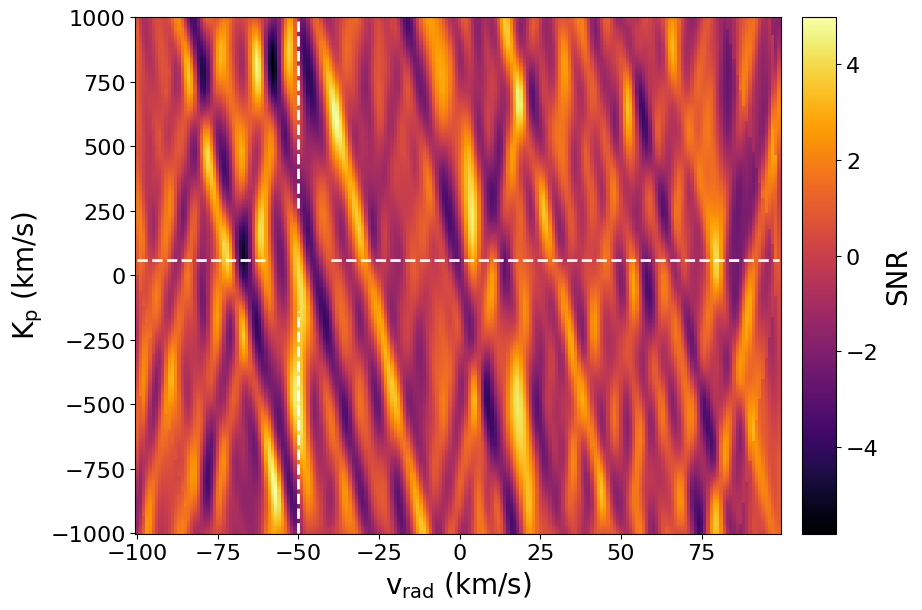

In [20]:
methods = [
        # 'ttest',
        # 'box',
        'clip'
          ]

# Choose Vrad (x-axis) Kp (y-axis) values for the plot
rv_grid = corrRV0
kp_grid = np.linspace(-1000, 1000, 400)

# # Set Vrad and Kp limits for the box in the box method
# box_Vrad = (70, 100)
# box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9

plot_all_orders = False  # plot the correlation map for each order

# Where to save figures
savefig = None #'/home/mathisb/Github/inj-1-pc.png'

#----------------------------------------------------------------#

KpVrad_list = []

for visit_name in nights_plot:

    ccf_obj = ccf_objects[visit_name]
    
    # Build the list of (npc, mask, obs) to plot for this night
    if n_pc_plot is not None and mask_wings_plot is not None:  # plot a single reduction
        combos = [(n_pc_plot,
                   mask_wings_plot,
                   all_obs[(visit_name, n_pc_plot, mask_wings_plot)])]
    else:                                                      # plot all reductions
        combos = [(npc, maskwings, obs)
                  for (visit, npc, maskwings), obs in all_obs.items()
                  if visit == visit_name]
    
    # Loop once over whatever we decided to plot
    for npc, maskwings, obs in combos:
        print(f"\033[1m{visit_name} | "
              f"nPC={npc}, mask_wings={maskwings/100:.2f}\033[0m")

        # Choose what orders to plot
        order_indices = pf.select_orders_plot(obs, wave_mod, model_spec, orders_to_delete=orders_to_delete.get(visit_name),
                                              max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm)
        
        if 'ttest' in methods:
            ccf_obj.ttest_map(obs, kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                          kp0=0, RV_limit=corr_xlim, kp_step=5, rv_step=2, RV=None, speed_limit=3,
                              icorr=obs.iIn, equal_var=False)
            
        if 'box' in methods:
            pf.calculate_KpVsys_map(obs, ccf_obj, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
                        box_Vrad=box_Vrad, box_Kp=box_Kp, savefig=savefig)
        
        if 'clip' in methods:
            KpVrad_map = pf.calculate_KpVsys_map(obs, ccf_obj, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter, savefig=savefig, output_map=True, expected_vrad=RV_inj, title=False)
            KpVrad_list.append(KpVrad_map)
        
        if plot_all_orders:
            print(f"\033[1m{visit_name} | "
                  f"nPC={npc}, mask_wings={maskwings/100:.2f}\033[0m")
            pf.plot_all_orders_correl(corrRV0, ccf_obj.data.squeeze(), obs, icorr=None, logl=False, sharey=True,
                              vrp=np.zeros_like(obs.vrp), RV_sys=0.0, vmin=None, vmax=None, vline=None,
                              hline=2, kind='snr', return_snr=False, orders=order_indices)


# Combined

In [54]:
# PARAMETERS FOR THE COMBINED CORRELATION

nPC = 0  # nPC to use

# NIGHTS TO COMBINE
file_arr = np.array([
                # SPIRou
                    # ['1', '2019-06-14', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-06-14.npz'],
                    # ['2', '2019-09-25', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-09-25.npz'],
                    # ['3', '2020-05-31', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-05-31.npz'],
                    # ['4', '2020-08-04', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-08-04.npz'],
                    # ['5', '2020-09-08', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-08.npz'],
                    # ['6', '2020-09-20', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-20.npz'],
                    # ['7', '2020-09-26', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-26.npz'],
                    # ['8', '2020-09-29', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-29.npz'],
                    # ['9', '2021-10-21', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-21.npz'],
                    # ['10', '2021-10-24', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-24.npz'],
                    # ['11', '2021-10-27', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-27.npz'],
                # NIRPS b
                    # ['1', '2023-09-07', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-09-07.npz'],
                    # ['2', '2024-07-05', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-07-05.npz'],
                    # ['3', '2024-07-11b', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-07-11b.npz'],
                # NIRPS d
                    ['1', '2023-06-08', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-06-08.npz'],
                    ['2', '2023-08-12', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-08-12.npz'],
                    ['3', '2023-08-24', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-08-24.npz'],
                    ['4', '2023-10-20', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-10-20.npz'],
                # NIRPS f
                    # ['1', '2023-08-28', f'sequence_{nPC}-pc_mask_wings97_data_trs_2023-08-28.npz'],
                    # ['2', '2024-11-02', f'sequence_{nPC}-pc_mask_wings97_data_trs_2024-11-02.npz'],
                    # ['3', '2025-08-06', f'sequence_{nPC}-pc_mask_wings97_data_trs_2025-08-06.npz'],
                    ],
                   dtype=object)

# Reduction parameters
kind_trans = 'transmission'  # emission or transmission
coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'  # limb darkening model

# Define cross-correlation axes
step_RV_inj = 1.0  # SPIROU: 2.14 (twice the resolution of SPIRou in km/s); NIRPS: 1.0
corr_xlim = 100  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

#-------------------------------------------------------------------------------------#

pl_obs.log.setLevel("WARNING")  # do not print entire log in this cell

# Correlation setup
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
combined_ccf = []
combined_logl = []
combined_obs = []
visit_dict = dict()
all_visits_str = ""

for reduc_idx, reduc in enumerate(file_arr):
    
    visit_nb = reduc[0]
    visit = reduc[1]
    fname = reduc[2]
    
    print("Loading", visit, "correlation...")
    
    # Where to find the reductions
    reduc_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit}/{reduction}')
    
    # Where to find the correlations
    corr_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit}/{reduction}')
    
    # Redefine planet (since mid-tr time changes for each visit)
    mid_tr = mid_tr_dict[visit]

    pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'mid_tr': mid_tr,
                 't_peri': mid_tr,
                 'excent': e,
                 'w': w}

    planet_obj = Planet(pl_name, **pl_kwargs)
    
    obs = pl_obs.load_single_sequences(fname, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)
    
    out_filename = f'{Path(fname).stem}_ccf_logl_seq_{model_name}'
    
    try:
        # Check if already generated
        saved_values = np.load(corr_dir / Path(out_filename + '.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model)
        ccf_map, logl_map = corr.calc_logl_injred(obs,'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(corr_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    

    all_visits_str += visit_nb + "-"
    
    visit_dict[str(reduc_idx + 1)] = obs
    combined_obs.append(obs)
    combined_ccf.append(ccf_map)
    combined_logl.append(logl_map)


transit_tags = [np.arange(obs.n_spec) for obs in visit_dict.values()]
all_visits = pl_obs.gen_merge_obs_sequence(obs, visit_dict, np.arange(1, len(file_arr) + 1), None, coeffs, ld_model, kind_trans, light=True)
all_visits.dt = np.concatenate([vst.dt for vst in visit_dict.values()])  # exposure times
all_visits_str = all_visits_str[:-1]
visit_dict[all_visits_str.replace("-", "")] = all_visits

pl_obs.log.setLevel("INFO")  # go back to normal log printing


Loading 2023-06-08 correlation...
Loading 2023-08-12 correlation...
Loading 2023-08-24 correlation...
Loading 2023-10-20 correlation...


Max value at 0 nPC = 0.41501934230852544 at -3.7113584693132786 km/s
Max value at 0 nPC = 0.38650281337262987 at -3.6503917972178375 km/s
Max value at 0 nPC = 0.38650281337262987 at -3.6503917972178375 km/s


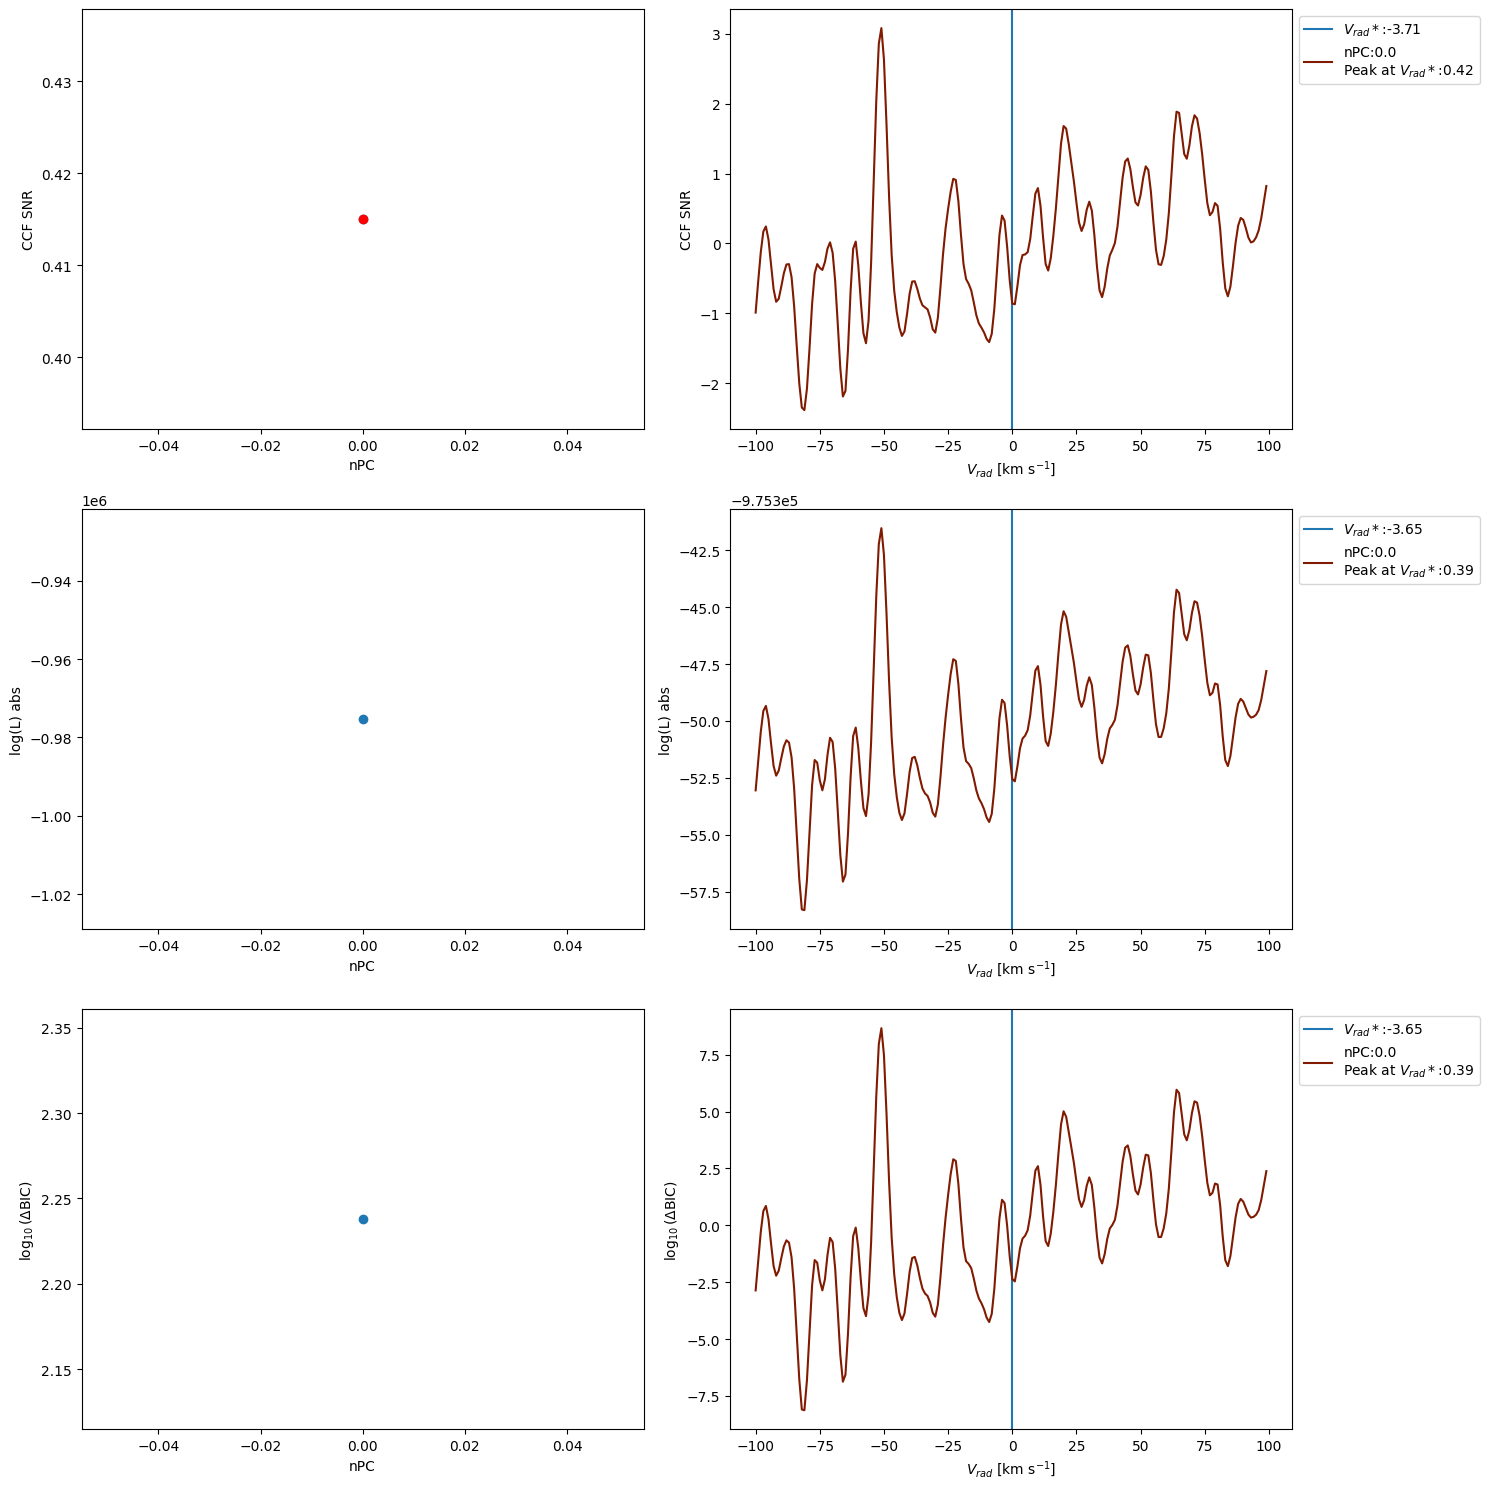

CCF SNR peak at Vrad*: [0.41501934]
log(L) abs peak at Vrad*: [-975349.07011229]
log_10(ΔBIC) peak at Vrad*: [2.23778424]
Saved file to :  /scratch/mathisb/HRS_correlations/NIRPS_Apr2026/TRAPPIST-1d/Combined/injected_H2rich_CH4_0.001_pcloud_100_at-50_scaling1/Figures/fig_CCF_2Dcombined_corr_nights1-2-3-4_pc0-0-0-0_mask_wings97-97-97-97_H2rich_CH4_0.001_pcloud_100_pc0.pdf
In-transit t-val = -0.23 / p-val 8.23e-01 / sig = -0.93
Out-of-transit t-val = 0.12 / p-val 9.06e-01 / sig = -1.32
T-val : Max value = -0.7 // Max position = -3.0
Histogram for Kp = 59.81 and RV = -3.71


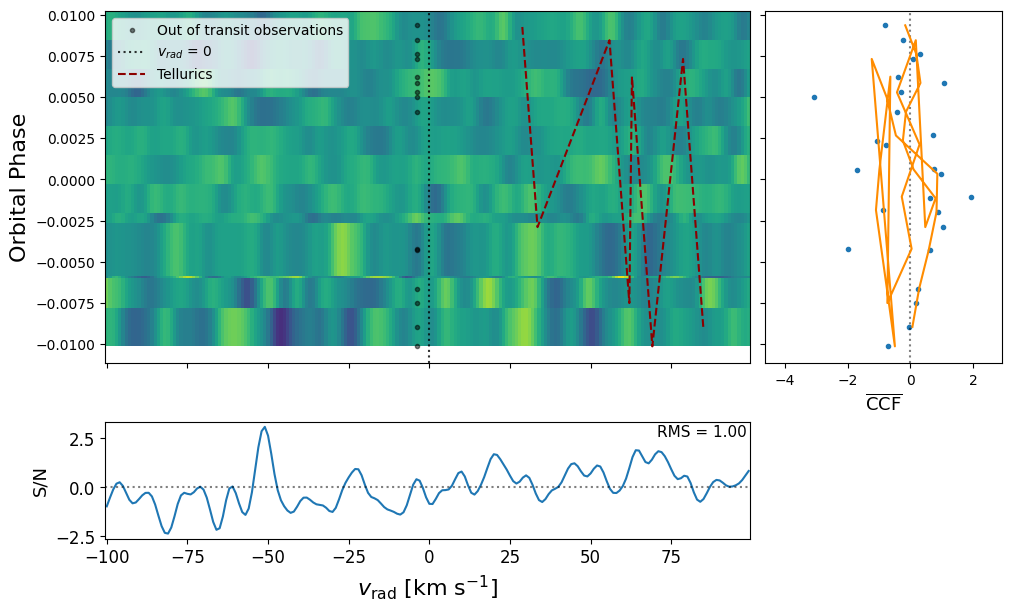

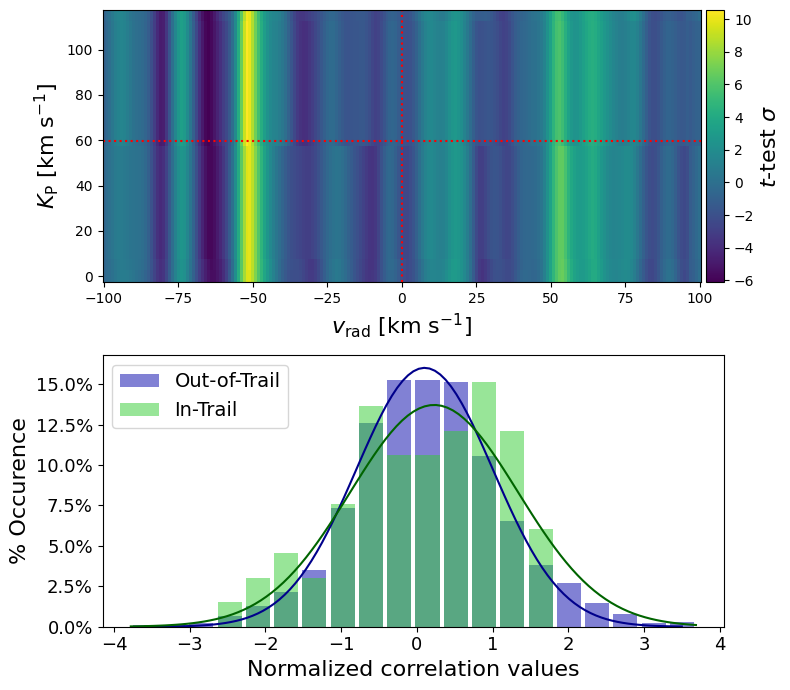

<Figure size 640x480 with 0 Axes>

In [55]:
# CRITERIA TO EXCLUDE AN ORDER

max_masked_ratio = 0.9  # excludes the orders where the ratio of masked data points is too high
min_SNR = 5            # excludes the orders where the instrument SNR is too low
min_model_ppm = 5       # excludes the orders where the model atmosphere is close to 0 ppm in transit depth

#-------------------------------------------------------------------------------------#

# Where to output the combined correlations
output_dir_comb = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/Combined/{reduction}')

# Figures directory
fig_dir_comb = str(output_dir_comb) + "/Figures/"
Path(fig_dir_comb).mkdir(parents=True, exist_ok=True)

# Create filename for combined correlation file
args_filename = []
        
for i in range(len(file_arr)):
    args_filename.append((str(visit_dict[str(i + 1)].params[5]), str(int(visit_dict[str(i + 1)].params[1] * 100))))

args_filename = ['-'.join(values) for values in zip(*args_filename)]
filename = 'combined_corr_nights{}'.format(all_visits_str) + '_pc{}_mask_wings{}_'.format(*args_filename) + f"{model_name}"


# Get list of obs objects
obs_list = list(visit_dict.values())[:-1]

# Choose what orders to plot
comb_orders_to_delete = pf.combined_orders_to_delete(orders_to_delete, file_arr[:,1])
idx_orders = pf.select_orders_plot(obs_list, wave_mod, model_spec, orders_to_delete=comb_orders_to_delete,
                                      max_masked_ratio=max_masked_ratio, min_SNR=min_SNR, min_model_ppm=min_model_ppm)

# Generate CCF
ccf_map_comb = np.concatenate(combined_ccf)
# logl_map = np.concatenate(combined_logl)

ccf_obj_comb = Correlations(ccf_map_comb, kind="logl", rv_grid=corrRV0, n_pcas=nPC, kp_array=Kp_array)
ccf_obj_comb.calc_ccf2d(all_visits, ccf=None, kind='logl_corr', id_pc=None, remove_mean=False, index=None, orders=idx_orders)

if nPC == 0:
    # Mask strong negative correlation regions
    ccf_sum_mask_list = []
    
    for c in combined_ccf:
        ccf_sum = np.sum(np.sum(c.squeeze()[:, idx_orders], axis=1), axis=0)  # sum of CCFs over orders and exposures
        noise_mask = ((np.abs(corrRV0) > 10) & (np.abs(corrRV0 - RV_inj) > 10))  # exclude RV region where planet and injected signals are located
    
        # Calculate MAD of CCF sum (like a std dev but without outliers)
        ccf_sum_med = np.median(ccf_sum[noise_mask])
        mad = np.median(np.abs(ccf_sum[noise_mask] - ccf_sum_med))
    
        ccf_sum_mask_list.append(ccf_sum < ccf_sum_med - 4 * mad)  # mask negative outlier regions
        
    combined_ccf_sum_mask = np.any(ccf_sum_mask_list, axis=0)
    ccf_obj_comb.map_prf[:, combined_ccf_sum_mask] = np.ma.masked


# ccf_obj_comb, logl_obj_comb = cc.plot_ccflogl(all_visits, 
#                                     ccf_map,
#                                     logl_map,
#                                     corrRV0, np.array([obs.Kp.value]),
#                                     [nPC], orders=idx_orders,
#                                     path_fig=fig_dir_comb,
#                                     fig_name=filename,
#                                     cmap='viridis'
#                                    )


# ccf_obj_comb.ttest_map(all_visits, kind='logl', vrp=np.zeros_like(all_visits.vrp), orders=idx_orders, kp0=0, cmap='viridis',
#                   RV_limit=100, kp_step=5, rv_step=1, RV=None, speed_limit=3, icorr=all_visits.iIn, equal_var=False)


# Save combined correlation
pl_obs.save_sequences(filename, visit_dict, [int(all_visits_str.replace("-", ""))], path=output_dir_comb, print_out=False)

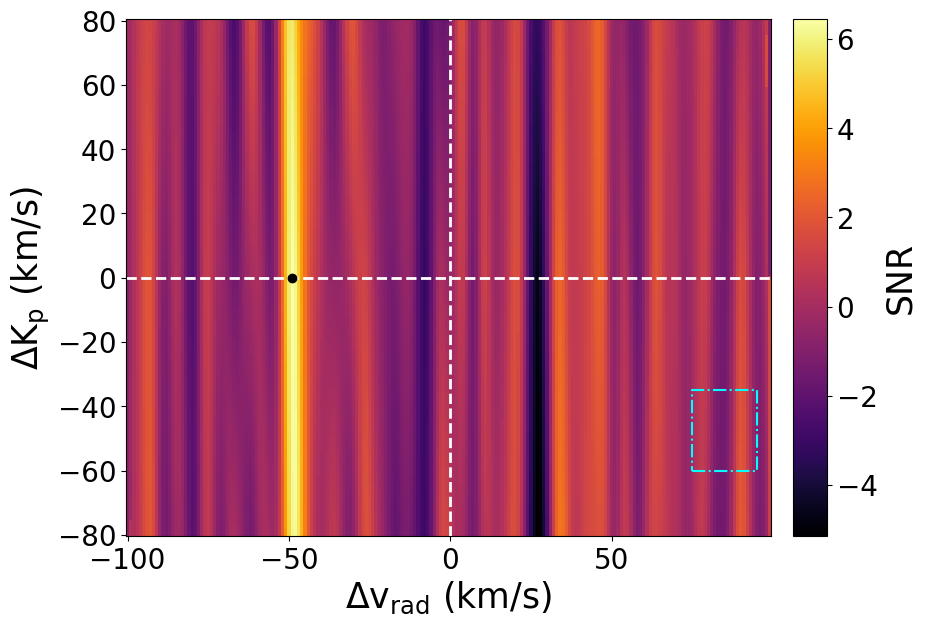

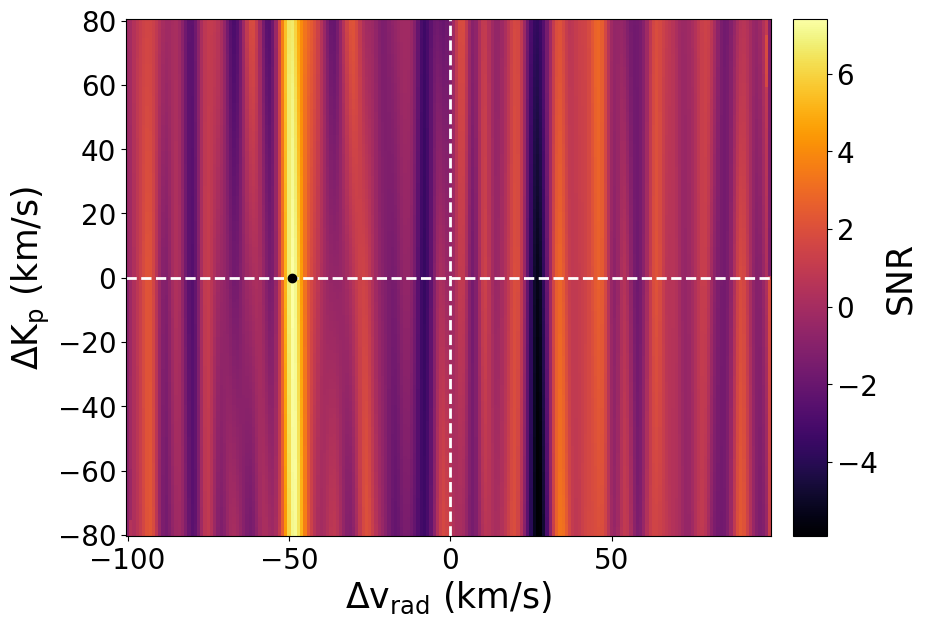

In [35]:
# BOX AND SIGMA-CLIPPING METHODS

# Choose Vrad (x-axis) Kp (y-axis) values
rv_grid = corrRV0
kp_grid = np.linspace(-1000, 1000, 400)

# # Set Vrad and Kp limits for the box in the box method
# box_Vrad = (75, 95)
# box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9

# Save a figure
# save_box = None
save_clip = None  # '/home/mathisb/Github/inj_KpVrad_d_CH4_2n_essai2'

#-----------------------------------------------------------------------------------------------#

# pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
#                         box_Vrad=box_Vrad, box_Kp=box_Kp, savefig=save_box)
pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter, expected_vrad=RV_inj, title=False, savefig=save_clip)